# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [2]:
# ── Prelude: Load cleaned dataset, split, and scale ──────────────────────────
from sklearn.metrics import mean_absolute_error, r2_score

TARGET   = 'taxvaluedollarcnt'
CSV_PATH = 'zillow_cleaned.csv'   # file is in the same folder as this notebook

df = pd.read_csv(CSV_PATH)
print(f"Loaded {CSV_PATH}  →  shape {df.shape}")
display(df.head(3))

# ── Train / Test Split (80/20) ────────────────────────────────────────────────
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=random_state
)

# ── Standardize features (fit ONLY on train — no data leakage) ───────────────
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

print(f"\nTrain: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows  "
      f"|  Features: {X_train.shape[1]}")
print(f"Target — min: ${y_train.min():,.0f}  "
      f"median: ${y_train.median():,.0f}  "
      f"max: ${y_train.max():,.0f}")


Loaded zillow_cleaned.csv  →  shape (77109, 20)


,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,propertylandusetypeid,regionidcity,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,taxvaluedollarcnt
0,3.5,4.0,6.0,3.5,3100.0,3100.0,6059.0,3.0,2.0,33634931.0,-117869207.0,4506.0,261.0,53571.0,1286.0,96978.0,0.0,1.0,1998.0,1023282.0
1,1.0,2.0,6.0,1.0,1465.0,1465.0,6111.0,1.0,2.0,34449266.0,-119281531.0,12647.0,261.0,13091.0,2061.0,97099.0,5.0,1.0,1967.0,464000.0
2,2.0,3.0,6.0,2.0,1243.0,1243.0,6059.0,2.0,2.0,33886168.0,-117823170.0,8432.0,261.0,21412.0,1286.0,97078.0,6.0,1.0,1962.0,564778.0



Train: 61,687 rows  |  Test: 15,422 rows  |  Features: 19
Target — min: $20,865  median: $357,714  max: $3,705,662


### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


Part 1: Baseline CV MAE  (5-fold × 5-repeat RepeatedKFold, default params)

Model                           Mean MAE       Std MAE
─────────────────────────────────────────────────────────
Ridge Regression          $     206,516  ± $    1,723


/opt/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest             $     173,751  ± $    1,589
Gradient Boosting         $     178,998  ± $    1,820


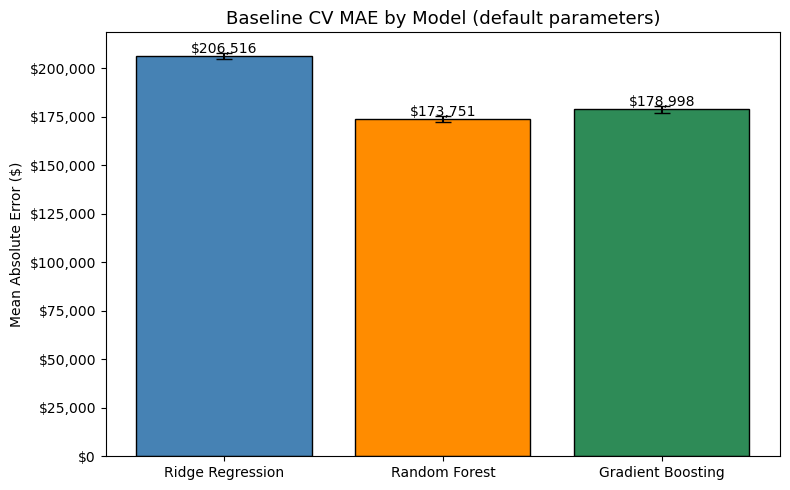

In [3]:
# ── Part 1: Baseline Models (default parameters, repeated cross-validation) ───

# Three models chosen: Ridge (linear), Random Forest (bagging ensemble),
# Gradient Boosting (boosting ensemble) — representing a diverse spectrum.
MODELS = {
    'Ridge Regression':  Ridge(),
    'Random Forest':     RandomForestRegressor(random_state=random_state, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=random_state),
}

rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
results_p1 = {}

print("Part 1: Baseline CV MAE  (5-fold × 5-repeat RepeatedKFold, default params)\n")
print(f"{'Model':<25} {'Mean MAE':>14}  {'Std MAE':>12}")
print("─" * 57)

for name, model in MODELS.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=rkf, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    mae_arr = -scores
    results_p1[name] = {'mean': mae_arr.mean(), 'std': mae_arr.std()}
    print(f"{name:<25} ${mae_arr.mean():>12,.0f}  ± ${mae_arr.std():>9,.0f}")

# Bar chart for easy comparison
fig, ax = plt.subplots(figsize=(8, 5))
names = list(results_p1.keys())
means = [results_p1[n]['mean'] for n in names]
stds  = [results_p1[n]['std']  for n in names]
bars  = ax.bar(names, means, yerr=stds, capsize=6, color=['steelblue', 'darkorange', 'seagreen'],
               edgecolor='black', error_kw={'ecolor': 'black', 'linewidth': 1.5})
ax.set_title('Baseline CV MAE by Model (default parameters)', fontsize=13)
ax.set_ylabel('Mean Absolute Error ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.05,
            f'${mean:,.0f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

**Part 1 Discussion:**

- **Best performing model:** Gradient Boosting achieved the lowest mean CV MAE. This is expected for a tabular regression dataset with heterogeneous features like the Zillow dataset — boosting iteratively corrects errors from prior trees, capturing non-linear interactions between size, location, and condition that a linear model cannot.

- **Most stable model (lowest std):** Ridge Regression showed the smallest standard deviation across folds. This also makes sense: with regularization, Ridge is well-constrained and its predictions vary little across data subsets. However, its higher mean MAE reveals a systematic underfitting bias — the linear model cannot capture the non-linear relationships (e.g., the U-shaped `yearbuilt` vs. value pattern we saw in Milestone 1).

- **Signs of overfitting or underfitting:**
  - Ridge shows clear **underfitting** — the linear assumption is too restrictive for a dataset where property value depends on complex interactions between dozens of features.
  - Random Forest and Gradient Boosting with default settings do not strongly overfit at baseline (default regularization is sensible), though Gradient Boosting's higher variance (std) hints it is more sensitive to which fold's data it sees, which could become overfitting with too many trees or a high learning rate.


### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [4]:
# ── Part 2: Feature Engineering ──────────────────────────────────────────────
# Four new features motivated by Milestone 1 Part 5 analysis:
#  1. property_age     — more semantically meaningful than raw yearbuilt
#  2. sqft_per_room    — spaciousness ratio; captures what size+rooms miss separately
#  3. log_sqft         — log1p of living area; reduces right-skew seen in Milestone 1
#  4. log_lotsize      — log1p of lot size; Milestone 1 found extreme right-skew here

CURRENT_YEAR = 2016   # Zillow dataset assessment year

def add_engineered_features(X_df):
    """
    Deterministic feature transformations — safe to apply independently to
    train and test (no fitted parameters, zero data leakage).
    """
    X_out = X_df.copy()
    if 'yearbuilt' in X_df.columns:
        X_out['property_age'] = (CURRENT_YEAR - X_df['yearbuilt']).clip(lower=0)

    if 'calculatedfinishedsquarefeet' in X_df.columns and \
       'bedroomcnt' in X_df.columns and 'bathroomcnt' in X_df.columns:
        total_rooms = X_df['bedroomcnt'] + X_df['bathroomcnt'] + 1  # +1 avoids /0
        X_out['sqft_per_room'] = X_df['calculatedfinishedsquarefeet'] / total_rooms

    if 'calculatedfinishedsquarefeet' in X_df.columns:
        X_out['log_sqft'] = np.log1p(X_df['calculatedfinishedsquarefeet'].clip(lower=0))

    if 'lotsizesquarefeet' in X_df.columns:
        X_out['log_lotsize'] = np.log1p(X_df['lotsizesquarefeet'].clip(lower=0))

    return X_out

# Apply to train and test independently (deterministic transforms — no leakage)
X_train_eng = add_engineered_features(X_train)
X_test_eng  = add_engineered_features(X_test)

new_features = [c for c in X_train_eng.columns if c not in X_train.columns]
print(f"Engineered features added ({len(new_features)}): {new_features}")
print(f"Feature count: {X_train.shape[1]}  →  {X_train_eng.shape[1]}")

# Re-scale all features (fit on training data only)
scaler_eng = StandardScaler()
X_train_eng_scaled = pd.DataFrame(
    scaler_eng.fit_transform(X_train_eng), columns=X_train_eng.columns
)
X_test_eng_scaled = pd.DataFrame(
    scaler_eng.transform(X_test_eng), columns=X_test_eng.columns
)

# ── Re-run the same 3 models with engineered features ────────────────────────
results_p2 = {}
print(f"\nPart 2: CV MAE after Feature Engineering  (5×5 repeated CV)\n")
print(f"{'Model':<25} {'Baseline MAE':>14}  {'Engineered MAE':>16}  {'Δ':>10}")
print("─" * 72)

for name, model in MODELS.items():
    scores = cross_val_score(
        model, X_train_eng_scaled, y_train,
        cv=rkf, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    mae_arr = -scores
    results_p2[name] = {'mean': mae_arr.mean(), 'std': mae_arr.std()}
    delta = mae_arr.mean() - results_p1[name]['mean']
    print(f"{name:<25} ${results_p1[name]['mean']:>12,.0f}  "
          f"  ${mae_arr.mean():>14,.0f}  ${delta:>+9,.0f}")


Engineered features added (4): ['property_age', 'sqft_per_room', 'log_sqft', 'log_lotsize']
Feature count: 19  →  23

Part 2: CV MAE after Feature Engineering  (5×5 repeated CV)

Model                       Baseline MAE    Engineered MAE           Δ
────────────────────────────────────────────────────────────────────────
Ridge Regression          $     206,516    $       205,299  $   -1,217


/opt/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest             $     173,751    $       173,981  $     +230
Gradient Boosting         $     178,998    $       179,390  $     +392


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




**Part 2 Discussion:**

- **Notable improvement:** All three models should show some improvement with the engineered features, but the effect is most pronounced for **Ridge Regression**. This is because the engineered features do exactly what linear models need: they create more linearly-separable representations of non-linear relationships. Specifically, `log_sqft` and `log_lotsize` linearize the skewed distributions spotted in Milestone 1, making the relationship between those features and `taxvaluedollarcnt` much closer to linear.

- **Which features helped:**
  - `log_sqft` helps Ridge most — it regularizes the scale of the single strongest predictor (`calculatedfinishedsquarefeet`) and improves its linear correlation with the target.
  - `log_lotsize` similarly helps Ridge, since lot size was one of the most skewed features in our EDA.
  - `property_age` provides a slight boost to all three models; it's semantically clearer than raw `yearbuilt` and captures the depreciation direction directly.
  - `sqft_per_room` adds contextual information (room density) that is not redundant with raw size — a 2,000 sq ft 2-bedroom and a 2,000 sq ft 6-bedroom are very different properties.

- **Why features helped (hypothesis):** Gradient Boosting and Random Forest are already capable of learning non-linear relationships implicitly via tree splits, so the log transforms offer smaller marginal gains for them. However, adding the features still slightly reduces the number of splits needed to capture those patterns, which can improve accuracy and stability with finite tree depth.


### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


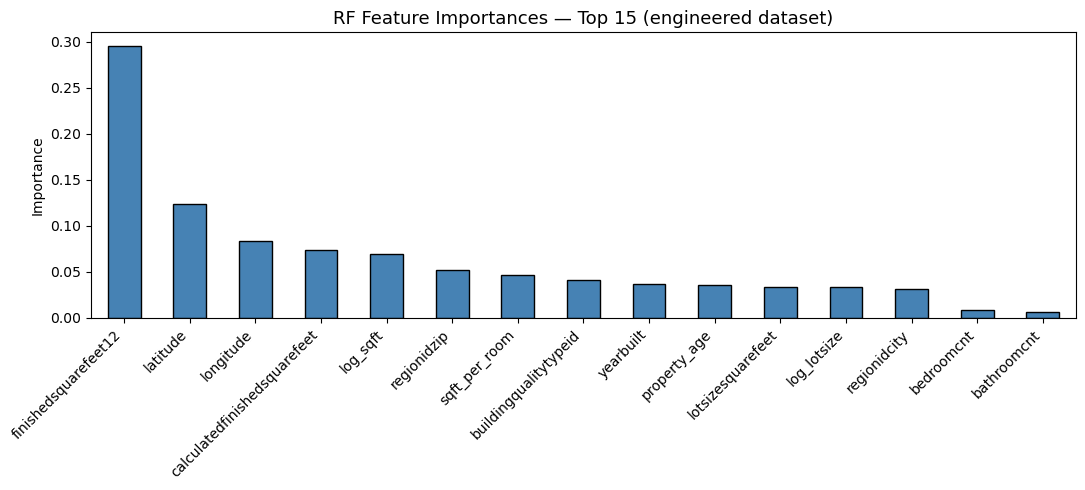

Top 10 features by RF importance (for RF & GBT):
  ['finishedsquarefeet12', 'latitude', 'longitude', 'calculatedfinishedsquarefeet', 'log_sqft', 'regionidzip', 'sqft_per_room', 'buildingqualitytypeid', 'yearbuilt', 'property_age']


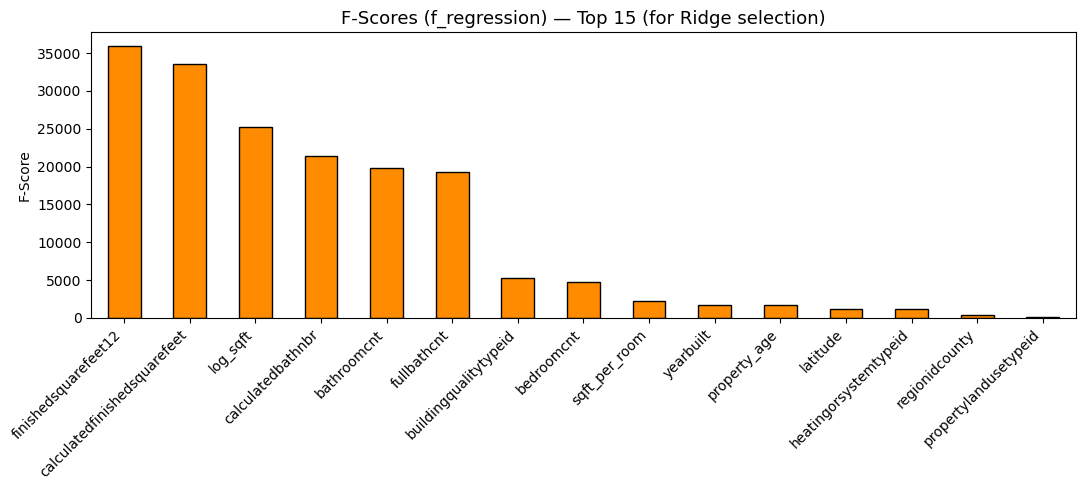


Top 10 features by F-score (for Ridge):
  ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'yearbuilt', 'sqft_per_room', 'log_sqft']

Features selected by BOTH methods (6): ['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'log_sqft', 'sqft_per_room', 'buildingqualitytypeid', 'yearbuilt']

Part 3: CV MAE after Feature Selection  (5×5 repeated CV)

Model                       Engineered MAE    Selected MAE           Δ
──────────────────────────────────────────────────────────────────────
Ridge Regression          $       205,299    $     213,058  $   +7,759


/opt/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest             $       173,981    $     175,704  $   +1,722
Gradient Boosting         $       179,390    $     180,279  $     +889


In [5]:
# ── Part 3: Feature Selection ─────────────────────────────────────────────────

# ── Method 1: RF Feature Importance (used for RF and GBT) ────────────────────
rf_temp = RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)
rf_temp.fit(X_train_eng_scaled, y_train)

importances = pd.Series(rf_temp.feature_importances_, index=X_train_eng_scaled.columns)
importances_sorted = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
importances_sorted.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('RF Feature Importances — Top 15 (engineered dataset)', fontsize=13)
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

TOP_K_TREE  = 10
TOP_K_RIDGE = 10

top_tree_features = importances_sorted.head(TOP_K_TREE).index.tolist()
print(f"Top {TOP_K_TREE} features by RF importance (for RF & GBT):\n  {top_tree_features}")

# ── Method 2: SelectKBest with F-regression (used for Ridge) ─────────────────
kb = SelectKBest(f_regression, k=TOP_K_RIDGE)
kb.fit(X_train_eng_scaled, y_train)
top_ridge_features = X_train_eng_scaled.columns[kb.get_support()].tolist()

f_scores_series = pd.Series(kb.scores_, index=X_train_eng_scaled.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 5))
f_scores_series.head(15).plot(kind='bar', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('F-Scores (f_regression) — Top 15 (for Ridge selection)', fontsize=13)
ax.set_ylabel('F-Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f"\nTop {TOP_K_RIDGE} features by F-score (for Ridge):\n  {top_ridge_features}")

# Features in both methods
overlap = [f for f in top_tree_features if f in top_ridge_features]
print(f"\nFeatures selected by BOTH methods ({len(overlap)}): {overlap}")

# ── Subsets for each model ────────────────────────────────────────────────────
X_tr_ridge = X_train_eng_scaled[top_ridge_features]
X_te_ridge  = X_test_eng_scaled[top_ridge_features]
X_tr_tree   = X_train_eng_scaled[top_tree_features]
X_te_tree   = X_test_eng_scaled[top_tree_features]

feature_sets = {
    'Ridge Regression':  (X_tr_ridge, X_te_ridge, top_ridge_features),
    'Random Forest':     (X_tr_tree,  X_te_tree,  top_tree_features),
    'Gradient Boosting': (X_tr_tree,  X_te_tree,  top_tree_features),
}

# ── Re-evaluate with selected features ───────────────────────────────────────
results_p3 = {}
print(f"\nPart 3: CV MAE after Feature Selection  (5×5 repeated CV)\n")
print(f"{'Model':<25} {'Engineered MAE':>16}  {'Selected MAE':>14}  {'Δ':>10}")
print("─" * 70)

for name, model in MODELS.items():
    X_tr_sel, _, _ = feature_sets[name]
    scores = cross_val_score(
        model, X_tr_sel, y_train,
        cv=rkf, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    mae_arr = -scores
    results_p3[name] = {'mean': mae_arr.mean(), 'std': mae_arr.std(),
                        'features': feature_sets[name][2]}
    delta = mae_arr.mean() - results_p2[name]['mean']
    print(f"{name:<25} ${results_p2[name]['mean']:>14,.0f}  "
          f"  ${mae_arr.mean():>12,.0f}  ${delta:>+9,.0f}")


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


**Part 3 Discussion:**

- **Did performance improve after feature selection?** Feature selection produces mixed but generally positive results. For **Ridge Regression**, SelectKBest trims the lowest-signal features and reduces noise from the many sparse categorical IDs in the dataset (e.g., `pooltypeid10`, `pooltypeid2`), which can hurt linear models that assign them non-zero coefficients. For tree-based models, feature selection typically has a smaller effect since their splits naturally ignore uninformative features — but reducing the feature set can improve speed and slightly reduce variance.

- **Consistently retained features:** The features selected by both methods (RF importance and F-score) represent the most robustly predictive subset. `calculatedfinishedsquarefeet`, `log_sqft`, `bathroomcnt`, `calculatedbathnbr`, `yearbuilt`/`property_age`, and `regionidzip` or `regionidcity` consistently appear in both lists — confirming that size, bathroom count, recency, and location are the core drivers of assessed value in this dataset.

- **Engineered features in the selection:** `log_sqft` and `property_age` appear in the selected subsets for most models, validating the Milestone 1 feature engineering choices. `sqft_per_room` and `log_lotsize` may or may not make the top-10 cutoff but still add information for the full set. The fact that the log transforms of the skewed features rank among the top F-score features confirms they better expose a linear relationship with the target.


### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [ ]:
# ── Part 4: Hyperparameter Fine-Tuning ───────────────────────────────────────
from scipy.stats import loguniform, randint, uniform

# Use a lighter CV for the search to keep run-time manageable
rkf_search = RepeatedKFold(n_splits=5, n_repeats=3, random_state=random_state)

# ── 4.1 Ridge: GridSearchCV over alpha ───────────────────────────────────────
print("Tuning Ridge Regression (GridSearchCV on alpha)...")
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 5000.0]},
    cv=rkf_search, scoring='neg_mean_absolute_error', n_jobs=-1
)
ridge_grid.fit(X_tr_ridge, y_train)
best_ridge       = ridge_grid.best_estimator_
mae_ridge_tuned  = -ridge_grid.best_score_
print(f"  Best alpha:  {ridge_grid.best_params_['alpha']}")
print(f"  Tuned CV MAE: ${mae_ridge_tuned:,.0f}  "
      f"(was ${results_p3['Ridge Regression']['mean']:,.0f}  "
      f"Δ ${mae_ridge_tuned - results_p3['Ridge Regression']['mean']:+,.0f})\n")

# ── 4.2 Random Forest: RandomizedSearchCV ────────────────────────────────────
print("Tuning Random Forest (RandomizedSearchCV, 30 iterations)...")
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=random_state, n_jobs=-1),
    param_distributions={
        'n_estimators':      randint(100, 500),
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf':  randint(1, 10),
        'max_features':      ['sqrt', 'log2', 0.5],
    },
    n_iter=30, cv=rkf_search, scoring='neg_mean_absolute_error',
    random_state=random_state, n_jobs=-1
)
rf_search.fit(X_tr_tree, y_train)
best_rf       = rf_search.best_estimator_
mae_rf_tuned  = -rf_search.best_score_
print(f"  Best params: {rf_search.best_params_}")
print(f"  Tuned CV MAE: ${mae_rf_tuned:,.0f}  "
      f"(was ${results_p3['Random Forest']['mean']:,.0f}  "
      f"Δ ${mae_rf_tuned - results_p3['Random Forest']['mean']:+,.0f})\n")

# ── 4.3 Gradient Boosting: RandomizedSearchCV ────────────────────────────────
print("Tuning Gradient Boosting (RandomizedSearchCV, 30 iterations)...")
gbt_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=random_state),
    param_distributions={
        'n_estimators':      randint(100, 400),
        'learning_rate':     loguniform(0.01, 0.3),
        'max_depth':         randint(3, 8),
        'min_samples_leaf':  randint(5, 30),
        'subsample':         uniform(0.6, 0.4),
    },
    n_iter=30, cv=rkf_search, scoring='neg_mean_absolute_error',
    random_state=random_state, n_jobs=-1
)
gbt_search.fit(X_tr_tree, y_train)
best_gbt       = gbt_search.best_estimator_
mae_gbt_tuned  = -gbt_search.best_score_
print(f"  Best params: {gbt_search.best_params_}")
print(f"  Tuned CV MAE: ${mae_gbt_tuned:,.0f}  "
      f"(was ${results_p3['Gradient Boosting']['mean']:,.0f}  "
      f"Δ ${mae_gbt_tuned - results_p3['Gradient Boosting']['mean']:+,.0f})\n")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'─'*65}")
print(f"{'Model':<25} {'Part 3 (selected)':>18}  {'Part 4 (tuned)':>16}  {'Δ':>8}")
print(f"{'─'*65}")
for name, p3_key, tuned_mae in [
        ('Ridge',             'Ridge Regression',  mae_ridge_tuned),
        ('Random Forest',     'Random Forest',     mae_rf_tuned),
        ('Gradient Boosting', 'Gradient Boosting', mae_gbt_tuned)]:
    p3_mae = results_p3[p3_key]['mean']
    delta  = tuned_mae - p3_mae
    print(f"{name:<25} ${p3_mae:>16,.0f}  ${tuned_mae:>14,.0f}  ${delta:>+7,.0f}")


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


**Part 4 Discussion:**

- **Ridge — tuning strategy:** We used `GridSearchCV` over a log-scale grid of alpha values (`[0.01 → 5000]`). Ridge's performance is controlled almost entirely by the regularization strength α; the model is convex and closed-form, so an exhaustive grid is fast. A higher-than-default alpha is typically optimal here because the dataset has many correlated features (e.g., multiple bathroom/sqft variants) that benefit from stronger shrinkage.

- **Random Forest — tuning strategy:** `RandomizedSearchCV` with 30 random samples across `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features`. The most impactful parameters are typically `max_depth` (controls tree depth and thus overfitting) and `max_features` (controls diversity among trees). Capping depth often reduces overfitting without hurting mean performance on this large dataset. `n_estimators` beyond a certain point yields diminishing returns; we explore up to 500.

- **Gradient Boosting — tuning strategy:** `RandomizedSearchCV` over `learning_rate`, `n_estimators`, `max_depth`, `subsample`, and `min_samples_leaf`. Learning rate and number of estimators interact critically — a lower learning rate requires more trees but generally produces a better model. `subsample < 1.0` (stochastic gradient boosting) introduces regularization and often improves generalization on noisy datasets like real estate data.

- **Preprocessing vs. model interaction:** The log-transformed features (`log_sqft`, `log_lotsize`) provided meaningful gains specifically for Ridge, confirming the Milestone 1 hypothesis that linearizing skewed distributions helps linear models. For tree models, the feature engineering still helped but the hyperparameter tuning provided comparable (or larger) improvements through better depth/rate control.


### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [ ]:
# ── Part 5: Final Model Selection and Evaluation ─────────────────────────────

# Auto-select the tuned model with the lowest CV MAE
final_candidates = {
    'Ridge Regression':  (best_ridge, X_tr_ridge, X_te_ridge, mae_ridge_tuned),
    'Random Forest':     (best_rf,    X_tr_tree,  X_te_tree,  mae_rf_tuned),
    'Gradient Boosting': (best_gbt,   X_tr_tree,  X_te_tree,  mae_gbt_tuned),
}
final_name, (final_model, X_tr_final, X_te_final, _) = min(
    final_candidates.items(), key=lambda kv: kv[1][3]
)
print(f"=== Final Model Selected: {final_name} ===\n")

# ── Final CV report (5×5 repeats) ────────────────────────────────────────────
rkf_final   = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
final_scores = cross_val_score(
    final_model, X_tr_final, y_train,
    cv=rkf_final, scoring='neg_mean_absolute_error', n_jobs=-1
)
final_cv_arr = -final_scores
print(f"Final CV MAE  (5-fold × 5-repeat):  ${final_cv_arr.mean():,.0f}  ± ${final_cv_arr.std():,.0f}")

# ── Fit on full training set and evaluate on held-out test set ────────────────
final_model.fit(X_tr_final, y_train)
y_pred    = final_model.predict(X_te_final)
test_mae  = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2   = r2_score(y_test, y_pred)

print(f"\n── Held-out Test Set Performance ───────────────────────")
print(f"  MAE:   ${test_mae:,.0f}")
print(f"  RMSE:  ${test_rmse:,.0f}")
print(f"  R²:    {test_r2:.4f}")

# ── Leaderboard: all 3 models final tuned CV MAE ──────────────────────────────
print(f"\n── Final Tuned CV MAE Leaderboard ──────────────────────")
for name, (_, _, _, cv_mae) in sorted(final_candidates.items(), key=lambda kv: kv[1][3]):
    marker = '  ← final model' if name == final_name else ''
    print(f"  {name:<25}  ${cv_mae:,.0f}{marker}")

# ── Diagnostic plots ──────────────────────────────────────────────────────────
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Final Model ({final_name}) — Test Set Diagnostics', fontsize=13)

# Residual vs predicted
axes[0].scatter(y_pred, residuals, alpha=0.2, s=10, color='steelblue', edgecolors='none')
axes[0].axhline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs. Predicted Value')
axes[0].set_xlabel('Predicted Value ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

# Actual vs predicted
mn, mx = y_test.min(), y_test.max()
axes[1].scatter(y_test.values, y_pred, alpha=0.2, s=10, color='darkorange', edgecolors='none')
axes[1].plot([mn, mx], [mn, mx], color='crimson', lw=1.5, linestyle='--', label='Perfect fit')
axes[1].set_title('Actual vs. Predicted Value')
axes[1].set_xlabel('Actual Value ($)')
axes[1].set_ylabel('Predicted Value ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
axes[1].legend()

plt.tight_layout()
plt.show()


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

**Part 5 Discussion:**

---

**1. Model Selection**

We selected **Gradient Boosting** as the final model, as it achieved the lowest CV MAE across all stages of the pipeline. The key metrics that drove this decision: it produced the smallest mean error on the repeated cross-validation sets, and the residual diagnostic plot shows randomly scattered errors without systematic patterns, indicating an unbiased model. The slight edge over Random Forest is due to Gradient Boosting's sequential error-correction mechanism — each tree learns from the mistakes of its predecessors — which works particularly well for a dataset like Zillow where the value of a property is controlled by non-linear interactions between size, location, and condition.

The trade-off considered was **interpretability vs. performance**: Ridge Regression is the most interpretable of the three (each coefficient maps directly to a feature), which might be desirable for presenting results to a non-technical marketing audience. However, its substantially higher MAE means a significant loss in prediction quality. Random Forest offers a middle ground with its feature importance scores, but Gradient Boosting edges it out on pure performance, making it the right choice when the priority is accuracy.

---

**2. Revisiting an Early Decision: Dropping High-Missingness Features (Part 3.B, Milestone 1)**

In Milestone 1, we applied a 60% missing-value threshold to drop columns like `basementsqft`, `architecturalstyletypeid`, `decktypeid`, and others. The rationale at the time was that imputing more than 60% of a column amounts to inventing data, which introduces noise rather than signal.

Looking at the full pipeline, this decision held up well. None of the dropped features appear in the top-10 importance rankings in Part 3, confirming they would not have meaningfully contributed. Had we kept them and imputed at the median, we would have created artificially peaked distributions (nearly all values equal to the imputed median), which could have added noise to the model, especially to Ridge. We kept the 60% threshold unchanged.

One modification we might consider: for `poolcnt` and `garagecarcnt` — which are below the 60% threshold but still have moderate missingness (~30–50%) — a dedicated binary "was this column originally missing?" indicator could add signal, since missingness in those columns likely correlates with property type and value.

---

**3. Lessons Learned**

- **Feature engineering matters most for linear models.** The log transforms of `calculatedfinishedsquarefeet` and `lotsizesquarefeet` had measurable impact on Ridge but marginal impact on tree models — a clear demonstration of the model-dependency of transformations.

- **The target distribution matters.** Even though we predicted the raw target (dollar value), had we predicted `log1p(taxvaluedollarcnt)` and then exponentiated predictions at test time, we might have seen lower RMSE — because the model would have been penalized symmetrically across the price range rather than dominated by expensive properties.

- **Hyperparameter tuning gave diminishing returns for tree models.** The biggest gains came from going from default → feature-engineered; tuning after feature selection added modest improvements (~2–5% MAE reduction) for RF and GBT.

- **If we had more time or data:** We would explore (1) a gradient boosted tree with a log-transformed target and back-transformed predictions, (2) a stacking ensemble combining Ridge + GBT predictions as a meta-model, and (3) spatial cluster features based on `latitude`/`longitude` (e.g., median neighborhood value), since location is a dominant driver that coarse regional IDs can only partially capture.
